# **Clustering**

In [ ]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: umap-learn in c:\users\samuele\appdata\local\programs\python\python313\lib\site-packages (0.5.9.post2)




[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install hdbscan


  Using cached hdbscan-0.8.40.tar.gz (6.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for hdbscan: filename=hdbscan-0.8.40-cp313-cp313-win_amd64.whl size=688243 sha256=bf7db19119a2be4c4f31d30c1657187f4801be9db91fb33bf83b6548d0bbed6a
  Stored in directory: c:\users\samuele\appdata\local\pip\cache\wheels\c3\72\af\f4d00f372c844119d65a75541288c9a23c23696de08a71b7ec
Successfully built hdbscan
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


approccio 2:sotto-clustering del cluster dominante 0 con DBSCAN

UMAP embedding shape: (14356, 2)
min_cluster_size=50 → Silhouette Score=0.1070
min_cluster_size=100 → Silhouette Score=0.0343
min_cluster_size=150 → Silhouette Score=-0.0266
min_cluster_size=200 → Silhouette Score=-0.0847
min_cluster_size=250 → Silhouette Score=-0.0814
min_cluster_size=300 → Silhouette Score=0.2053

Miglior silhouette: 0.2053 con min_cluster_size = 300

Distribuzione percentuale dei cluster:
Cluster 0: 4.83%
Cluster 1: 3.45%
Cluster 2: 4.62%
Cluster 3: 5.50%
Cluster 4: 9.31%
Cluster 5: 6.45%
Cluster 6: 65.83%
         usB1BCilPres_M3  usB1BCilPres_M1  usB2BCilPres_M3  usB2BCilPres_M1  \
Cluster                                                                       
0               1.566183         1.629212         1.558112         1.618734   
1               1.386134         1.416483         1.374709         1.407093   
2               1.881887         1.806377         1.868460         1.795792   
3               2.005738         2.071876         1.990801         2.0598

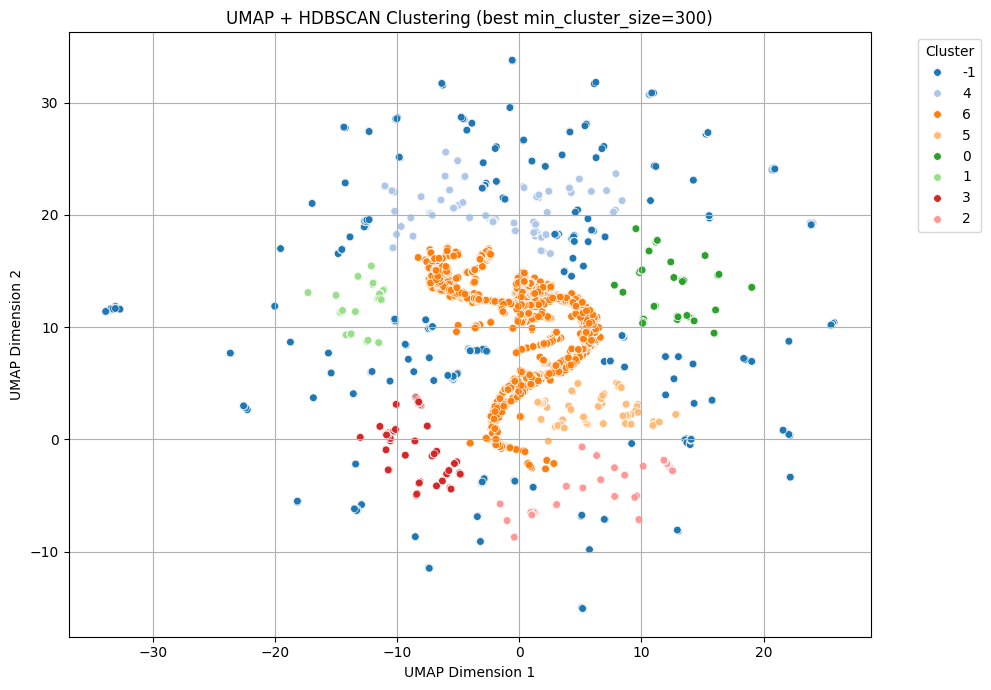

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import hdbscan
import umap.umap_ as umap
from sklearn.neighbors import NearestNeighbors
import warnings

warnings.filterwarnings('ignore')

# Caricamento e pulizia dataset
df = pd.read_csv("dataset_cleaned.csv")
df.dropna(inplace=True)
df = df.select_dtypes(include=[np.number])

# Selezione feature
pca1_columns = ['usB1BCilPres_M3', 'usB1BCilPres_M1', 'usB2BCilPres_M3', 'usB2BCilPres_M1', 
                'usB1BCilPres_M6', 'usB2BCilPres_M6', 'usB2BCilPres_T7', 'usB1BCilPres_T7', 
                'usB2BCilPres_T4', 'usB1BCilPres_T4']
pca2_columns = ['HMI_VBatt_T2', 'HMI_VBatt_T4', 'HMI_VBatt_T5', 'HMI_VBatt_T7']
selected_features = pca1_columns + pca2_columns
df_selected = df[selected_features].copy()

# Standardizzazione
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_selected)

# UMAP embedding
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(data_scaled)
print(f"UMAP embedding shape: {embedding.shape}")

# Filtra outlier estremi
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(embedding)
#matrice con le distanze dai 10 vicini più vicini per ogni punto
distances, _ = neighbors_fit.kneighbors(embedding)
#prende solo i vicini dal secondo in poi (esclude il primo che è sempre il punto stesso con distanza 0)
mean_distances = distances[:, 1:].mean(axis=1)
threshold = np.percentile(mean_distances, 98)  # rimozione 2% dei dati piu' isolati
#True se il punto è vicino ad altri, False se è tra i più isolati del 2%
mask = mean_distances < threshold
#toglie automaticamente tutte le righe con False
embedding_filtered = embedding[mask]
df_filtered = df[mask].copy()

# Trova il miglior min_cluster_size per HDBSCAN
best_score = -1
best_labels = None
best_mcs = None
for mcs in range(50, 301, 50):  
    """
    min_cluster= numero minimo di punti per formare un cluster valido , min_samples = quanto un punto deve essere denso per essere considerato “core” e non rumore
    cluster_selection_epsilon =  decide se due cluster simili possono essere uniti.
    """

    clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=10, cluster_selection_epsilon=0.5)
    labels = clusterer.fit_predict(embedding_filtered)  # Usa embedding_filtered
    mask_cluster = labels != -1
    if len(np.unique(labels[mask_cluster])) > 1:
        score = silhouette_score(embedding_filtered[mask_cluster], labels[mask_cluster])
        print(f"min_cluster_size={mcs} → Silhouette Score={score:.4f}")
        if score > best_score:
            best_score = score
            best_labels = labels
            best_mcs = mcs

print(f"\nMiglior silhouette: {best_score:.4f} con min_cluster_size = {best_mcs}")

# Assegna i cluster finali
df_filtered['Cluster'] = best_labels

# Elimina le tuple con Cluster == -1
df_filtered_no_outliers = df_filtered[df_filtered['Cluster'] != -1].copy()

# Frequenza dei cluster (solo cluster validi)
cluster_freq = df_filtered_no_outliers['Cluster'].value_counts(normalize=True).sort_index() * 100
print("\nDistribuzione percentuale dei cluster:")
for cluster, freq in cluster_freq.items():
    print(f"Cluster {cluster}: {freq:.2f}%")

#  Calcolo medie delle feature per ogni cluster (utile per caratterizzare i cluster)
durata = ['Durata'] if 'Durata' in df.columns else []
colonne_finali = pca1_columns + pca2_columns + durata
df_mediato = df_filtered_no_outliers.groupby('Cluster')[colonne_finali].mean()

# Salvataggio medie
pd.set_option('display.max_columns', None)
print(df_mediato)
df_mediato.to_csv("medie_cluster_HDBSCAN.csv")

# Salvataggio CSV
output_csv = "dataset_con_clusters_HDBSCAN.csv"
df_filtered_no_outliers.to_csv(output_csv, index=False)
print(f"\nNuovo dataset salvato in: {output_csv}")

# Visualizzazione (include gli outlier)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=embedding_filtered[:, 0], 
                y=embedding_filtered[:, 1], 
                hue=df_filtered['Cluster'].astype(str),  # Converti in stringa per gestire -1
                palette='tab20', s=30)
plt.title(f'UMAP + HDBSCAN Clustering (best min_cluster_size={best_mcs})')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Single Copule**

In [2]:
pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import umap.umap_ as umap
from copulas.multivariate import GaussianMultivariate
import pickle
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Caricamento del dataset
df_copula = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")
num_righe = 1000

# Standardizzazione dei dati (necessaria per UMAP e per uniformità)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_copula.drop(columns=['Cluster']))

Copula e annesso fitting dei dati

In [ ]:
# Adatta la copula multivariata
copula_generator = GaussianMultivariate()
# Eliminiamo la colonna Cluster dato che stiamo trattando un modello non condizionale
copula_generator.fit(df_copula.drop(columns=['Cluster']))


# Salva il modello della copula ( per poterlo riutilizzare altre volte già addestrato)
with open('copula_model.pkl', 'wb') as f:
    pickle.dump(copula_generator, f)

Generazione dati

In [15]:
# Genera dati sintetici
num_synthetic = 2500
df_synthetic = copula_generator.sample(num_synthetic)


# Salva i dati sintetici in un CSV
output_csv = "outfit_copy/output_copula_semplice/dataset_synthetic_copula.csv"
df_synthetic.to_csv(output_csv, index=False)
print(f"\nDati sintetici salvati in: {output_csv}")


Dati sintetici salvati in: outfit_copy/output_copula_semplice/dataset_synthetic_copula.csv


Metriche di valutazione: matrice di correlazione e ks test

In [2]:
import pandas as pd
# Copia dati originali
df_with_cluster = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")

# Salva la colonna Cluster separata
cluster_col = df_with_cluster['Cluster']

# Rimuovi Cluster per il calcolo della correlazione
df_no_cluster = df_with_cluster.drop(columns=['Cluster'])

# Calcola matrice di correlazione
corr_matrix_original = df_no_cluster.corr()

# Riaggiungi colonna Cluster in ultima posizione
corr_matrix_original['Cluster'] = cluster_col

# Salva
corr_matrix_original.to_csv("outfit_copy/corr_matrix_original.csv", index=False)

print("\n Matrice di correlazione originale salvata in: corr_matrix_original.csv")




 Matrice di correlazione originale salvata in: corr_matrix_original.csv


In [5]:
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import mutual_info_score
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon


# Carica dataset reale e sintetico
df_real = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")
df_synthetic = pd.read_csv("outfit_copy/output_copula_semplice/dati_sintetici_generati_copula.csv")

# Calcola la matrice di correlazione dei dati sintetici
corr_matrix_synthetic = df_synthetic.corr()
corr_matrix_synthetic.to_csv("outfit_copy/output_copula_semplice/corr_matrix_copula.csv")
print("\n Matrice di correlazione salvata in: outfit_copy/output_copula_semplice/corr_matrix_copula.csv")

# Lista delle feature numeriche in comune
numeric_features = df_real.select_dtypes(include=[np.number]).columns.intersection(df_synthetic.columns)

# Dizionari per salvare le metriche
ks_results = {}
wasserstein_results = {}
mae_stats_results = {}
mutual_info_results = {}
js_results = {}

for feature in numeric_features:
    real_values = df_real[feature].dropna()
    synthetic_values = df_synthetic[feature].dropna()

    # Campiona real_values per uguagliare lunghezza
    if len(real_values) > len(synthetic_values):
        real_values_sampled = np.random.choice(real_values, size=len(synthetic_values), replace=False)
        synthetic_values_sampled = synthetic_values.values
    else:
        real_values_sampled = real_values.values
        synthetic_values_sampled = np.random.choice(synthetic_values, size=len(real_values), replace=False)


    # Test KS
    ks_stat, ks_pvalue = ks_2samp(real_values, synthetic_values)
    ks_results[feature] = {'KS Statistic': ks_stat, 'p-value': ks_pvalue}

    # Distanza di Wasserstein
    wasser = wasserstein_distance(real_values, synthetic_values)
    wasserstein_results[feature] = {'Wasserstein Distance': wasser}

    # MAE su media e varianza
    mean_diff = np.abs(np.mean(real_values) - np.mean(synthetic_values))
    var_diff = np.abs(np.var(real_values) - np.var(synthetic_values))
    mae_stats_results[feature] = {
        'Mean Difference': mean_diff,
        'Variance Difference': var_diff
    }


    # Mutual Information (discretizzata su 20 bin)
    bins = 20
    real_disc = np.digitize(real_values_sampled, bins=np.histogram_bin_edges(real_values, bins=bins))
    synth_disc = np.digitize(synthetic_values_sampled, bins=np.histogram_bin_edges(synthetic_values, bins=bins))
    mi_score = mutual_info_score(real_disc, synth_disc)
    mutual_info_results[feature] = {'Mutual Information': mi_score}

    # Jensen-Shannon Distance
    hist_real, _ = np.histogram(real_values, bins=20, density=True)
    hist_synth, _ = np.histogram(synthetic_values, bins=20, density=True)
    js_dist = jensenshannon(hist_real + 1e-12, hist_synth + 1e-12)  # Avoid div by zero
    js_results[feature] = {'JS Distance': float(js_dist)}

# Converti in DataFrame
ks_df = pd.DataFrame(ks_results).T
wasser_df = pd.DataFrame(wasserstein_results).T
mae_stats_df = pd.DataFrame(mae_stats_results).T
mi_df = pd.DataFrame(mutual_info_results).T
js_df = pd.DataFrame(js_results).T

# Salvataggio CSV
ks_df.to_csv("outfit_copy/output_copula_semplice/ks_comparison_copula.csv")
wasser_df.to_csv("outfit_copy/output_copula_semplice/wasserstein_copula.csv")
mae_stats_df.to_csv("outfit_copy/output_copula_semplice/mae_stats_copula.csv")
mi_df.to_csv("outfit_copy/output_copula_semplice/mutual_info_copula.csv")
js_df.to_csv("outfit_copy/output_copula_semplice/js_distance_copula.csv")

print("\n Risultati KS salvati in: outfit_copy/output_copula_semplice/ks_comparison_copula.csv")
print(" Distanza di Wasserstein salvata in: outfit_copy/output_copula_semplice/wasserstein_copula.csv")
print(f" Mae salvata in outfit_copy/output_copula_semplice/mae_stats_copula.csv")
print(" Mutual Information salvata in: oufit_copy/output_copula_semplice/mutual_info_copula.csv")
print(" JS Distance salvata in: outfit_copy/output_copula_semplice/js_distance_copula.csv")



 Matrice di correlazione salvata in: outfit_copy/output_copula_semplice/corr_matrix_copula.csv

 Risultati KS salvati in: outfit_copy/output_copula_semplice/ks_comparison_copula.csv
 Distanza di Wasserstein salvata in: outfit_copy/output_copula_semplice/wasserstein_copula.csv
 Mae salvata in outfit_copy/output_copula_semplice/mae_stats_copula.csv
 Mutual Information salvata in: oufit_copy/output_copula_semplice/mutual_info_copula.csv
 JS Distance salvata in: outfit_copy/output_copula_semplice/js_distance_copula.csv


Visualizzazione UMAP 

c:\Users\samuele\OneDrive\Desktop\progetto_tesi\gan_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


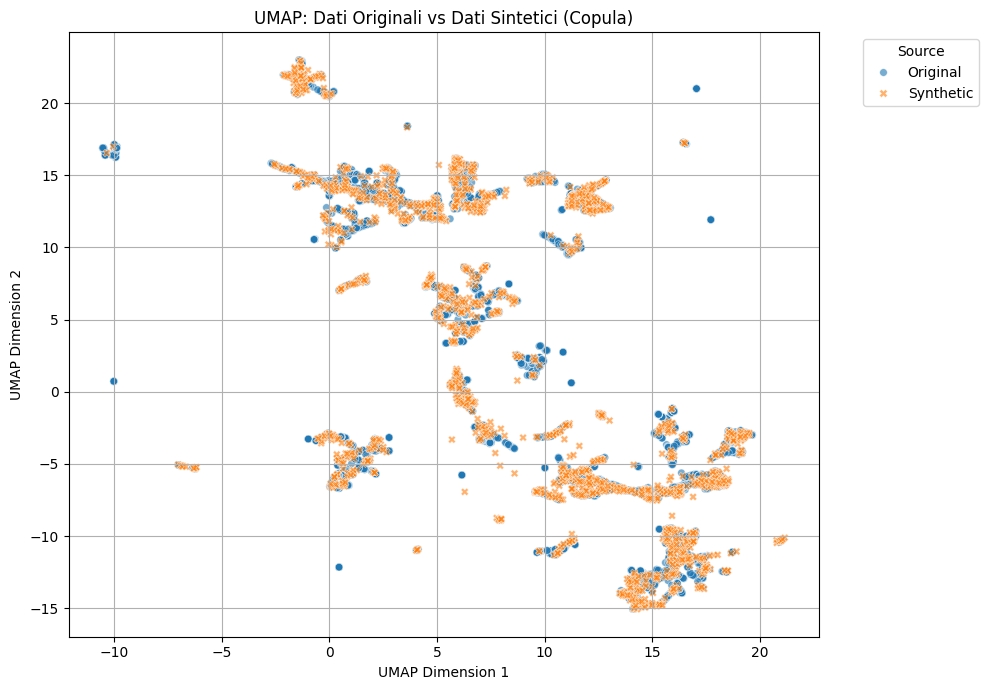

In [25]:
# Visualizzazione UMAP
# Standardizza i dati sintetici per UMAP
synthetic_scaled = scaler.transform(df_synthetic)

# Esegui UMAP sui dati originali e sintetici
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
embedding_original = reducer.fit_transform(data_scaled)
embedding_synthetic = reducer.transform(synthetic_scaled)  # Usa transform per consistenza

# Crea un DataFrame per la visualizzazione
df_plot = pd.DataFrame({
    'UMAP1': np.concatenate([embedding_original[:, 0], embedding_synthetic[:, 0]]),
    'UMAP2': np.concatenate([embedding_original[:, 1], embedding_synthetic[:, 1]]),
    'Source': ['Original'] * len(embedding_original) + ['Synthetic'] * len(embedding_synthetic)
})

# Plot UMAP
plt.figure(figsize=(10, 7))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Source', style='Source', data=df_plot, s=30, alpha=0.6)
plt.title('UMAP: Dati Originali vs Dati Sintetici (Copula)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Copule with cluster**

In [28]:
pip install copulas

  Using cached copulas-0.12.3-py3-none-any.whl.metadata (9.5 kB)
  Using cached plotly-6.2.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-1.48.1-py3-none-any.whl.metadata (11 kB)
Using cached copulas-0.12.3-py3-none-any.whl (52 kB)
Using cached plotly-6.2.0-py3-none-any.whl (9.6 MB)
Using cached narwhals-1.48.1-py3-none-any.whl (377 kB)

   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhal

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
from copulas.multivariate import GaussianMultivariate
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Caricamento del dataset
df_originale = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")
num_righe = 2500




Una copula per ogni cluster

In [42]:
# Calcola la distribuzione dei cluster (proporzioni)
cluster_freq = df_originale['Cluster'].value_counts(normalize=True)
print("\nDistribuzione percentuale dei cluster nel dataset originale:")
for cluster, freq in cluster_freq.items():
    print(f"Cluster {cluster}: {freq*100:.2f}%")

# Dizionari per i DataFrame e i generatori di copula per ogni cluster
cluster_dataframes = {}
cluster_generators = {}

# Adatta una copula per ogni cluster
for cluster_num in df_originale['Cluster'].unique():
    print(f"\nAdattamento copula per Cluster {cluster_num}")
    # Filtra i dati del cluster
    cluster_df = df_originale[df_originale['Cluster'] == cluster_num].copy()
    if len(cluster_df) > 1:  # Assicurati che ci siano abbastanza dati per la copula
        cluster_dataframes[cluster_num] = cluster_df
        cluster_generators[cluster_num] = GaussianMultivariate()
        cluster_generators[cluster_num].fit(cluster_df)
    else:
        print(f"Cluster {cluster_num} ha troppo pochi dati, saltato.")



Distribuzione percentuale dei cluster nel dataset originale:
Cluster 6: 65.83%
Cluster 4: 9.31%
Cluster 5: 6.45%
Cluster 3: 5.50%
Cluster 0: 4.83%
Cluster 2: 4.62%
Cluster 1: 3.45%

Adattamento copula per Cluster 4

Adattamento copula per Cluster 6

Adattamento copula per Cluster 5

Adattamento copula per Cluster 0

Adattamento copula per Cluster 1

Adattamento copula per Cluster 3

Adattamento copula per Cluster 2


Generazione dati per ogni cluster

In [43]:
# Genera dati sintetici per ogni cluster
generated_records = []
for cluster_num in cluster_generators:
    # Calcola il numero di righe sintetiche proporzionale alla frequenza del cluster
    probability = cluster_freq.get(cluster_num, 0)
    samples_to_produce = int(probability * num_righe)
    if samples_to_produce > 0:
        print(f"Cluster {cluster_num} genererà {samples_to_produce} campioni")
        cluster_records = cluster_generators[cluster_num].sample(samples_to_produce)
        cluster_records['Cluster'] = cluster_num  # Aggiungi la colonna Cluster
        generated_records.append(cluster_records)
    else:
        print(f"Cluster {cluster_num} ha probabilità 0, saltato.")

# Combina i dati sintetici
df_synthetic = pd.concat(generated_records, ignore_index=True)

# Salva i dati sintetici in un CSV
output_csv = "outfit_copy/output_copula_clusters/dati_sintetici_generati_copula_clusters.csv"
df_synthetic.to_csv(output_csv, index=False)
print(f"\n Dati sintetici salvati in: {output_csv}")


Cluster 4 genererà 232 campioni
Cluster 6 genererà 1645 campioni
Cluster 5 genererà 161 campioni
Cluster 0 genererà 120 campioni
Cluster 1 genererà 86 campioni
Cluster 3 genererà 137 campioni
Cluster 2 genererà 115 campioni

 Dati sintetici salvati in: outfit_copy/output_copula_clusters/dati_sintetici_generati_copula_clusters.csv


Metriche di valutazione

In [6]:
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import mutual_info_score
import pandas as pd
import numpy as np

# Carica dataset reale e sintetico
df_real = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")
df_synthetic = pd.read_csv("outfit_copy/output_copula_clusters/dati_sintetici_generati_copula_clusters.csv")

# Calcola la matrice di correlazione dei dati sintetici

"""
cluster_syn = df_synthetic['Cluster']
df_syn_no_cluster = df_synthetic.drop(columns=['Cluster'])
corr_matrix_synthetic = df_syn_no_cluster.corr()
corr_matrix_synthetic['Cluster'] = cluster_syn
corr_matrix_synthetic.to_csv("outfit_copy/output_copula_clusters/corr_matrix_copula_clusters.csv")
"""
corr_matrix_synthetic = df_synthetic.corr()
corr_matrix_synthetic.to_csv("outfit_copy/output_copula_clusters/corr_matrix_copula_clusters.csv")
print("\n Matrice di correlazione salvata in: output_copula_clusters/corr_matrix_copula_clusters.csv")

# Lista delle feature numeriche in comune
numeric_features = df_real.select_dtypes(include=[np.number]).columns.intersection(df_synthetic.columns)

# Dizionari per salvare le metriche
ks_results = {}
wasserstein_results = {}
mae_stats_results = {}
mutual_info_results = {}
js_results = {}

for feature in numeric_features:
    real_values = df_real[feature].dropna()
    synthetic_values = df_synthetic[feature].dropna()

    # Campiona real_values per uguagliare lunghezza
    if len(real_values) > len(synthetic_values):
        real_values_sampled = np.random.choice(real_values, size=len(synthetic_values), replace=False)
        synthetic_values_sampled = synthetic_values.values
    else:
        real_values_sampled = real_values.values
        synthetic_values_sampled = np.random.choice(synthetic_values, size=len(real_values), replace=False)


    # Test KS
    ks_stat, ks_pvalue = ks_2samp(real_values, synthetic_values)
    ks_results[feature] = {'KS Statistic': ks_stat, 'p-value': ks_pvalue}

    # Distanza di Wasserstein
    wasser = wasserstein_distance(real_values, synthetic_values)
    wasserstein_results[feature] = {'Wasserstein Distance': wasser}

    # MAE su media e varianza
    mean_diff = np.abs(np.mean(real_values) - np.mean(synthetic_values))
    var_diff = np.abs(np.var(real_values) - np.var(synthetic_values))
    mae_stats_results[feature] = {
        'Mean Difference': mean_diff,
        'Variance Difference': var_diff
    }


    # Mutual Information (discretizzata su 20 bin)
    bins = 20
    real_disc = np.digitize(real_values_sampled, bins=np.histogram_bin_edges(real_values, bins=bins))
    synth_disc = np.digitize(synthetic_values_sampled, bins=np.histogram_bin_edges(synthetic_values, bins=bins))
    mi_score = mutual_info_score(real_disc, synth_disc)
    mutual_info_results[feature] = {'Mutual Information': mi_score}

    # Jensen-Shannon Distance
    hist_real, _ = np.histogram(real_values, bins=20, density=True)
    hist_synth, _ = np.histogram(synthetic_values, bins=20, density=True)
    js_dist = jensenshannon(hist_real + 1e-12, hist_synth + 1e-12)  # Avoid div by zero
    js_results[feature] = {'JS Distance': float(js_dist)}

# Converti in DataFrame
ks_df = pd.DataFrame(ks_results).T
wasser_df = pd.DataFrame(wasserstein_results).T
mae_stats_df = pd.DataFrame(mae_stats_results).T
mi_df = pd.DataFrame(mutual_info_results).T
js_df = pd.DataFrame(js_results).T

# Salvataggio CSV
ks_df.to_csv("outfit_copy/output_copula_clusters/ks_comparison_copula_clusters.csv")
wasser_df.to_csv("outfit_copy/output_copula_clusters/wasserstein_copula_clusters.csv")
mae_stats_df.to_csv("outfit_copy/output_copula_clusters/mae_stats_copula_clusters.csv")
mi_df.to_csv("outfit_copy/output_copula_clusters/mutual_info_copula_clusters.csv")
js_df.to_csv("outfit_copy/output_copula_clusters/js_distance_copula_clusters.csv")

print("\n Risultati KS salvati in: outfit_copy/output_copula_clusters/ks_comparison_copula_clusters.csv")
print(" Distanza di Wasserstein salvata in: outfit_copy/output_copula_clusters/wasserstein_copula_clusters.csv")
print(f" Mae salvata in outfit_copy/output_copula_clusters/mae_stats_copula_clusters.csv")
print(" Mutual Information salvata in: oufit_copy/output_copula_clusters/mutual_info_copula_clusters.csv")
print(" JS Distance salvata in: outfit_copy/output_copula_clusters/js_distance_copula_clusters.csv")




 Matrice di correlazione salvata in: output_copula_clusters/corr_matrix_copula_clusters.csv

 Risultati KS salvati in: outfit_copy/output_copula_clusters/ks_comparison_copula_clusters.csv
 Distanza di Wasserstein salvata in: outfit_copy/output_copula_clusters/wasserstein_copula_clusters.csv
 Mae salvata in outfit_copy/output_copula_clusters/mae_stats_copula_clusters.csv
 Mutual Information salvata in: oufit_copy/output_copula_clusters/mutual_info_copula_clusters.csv
 JS Distance salvata in: outfit_copy/output_copula_clusters/js_distance_copula_clusters.csv


Visualizzazione UMAP

c:\Users\samuele\OneDrive\Desktop\progetto_tesi\gan_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


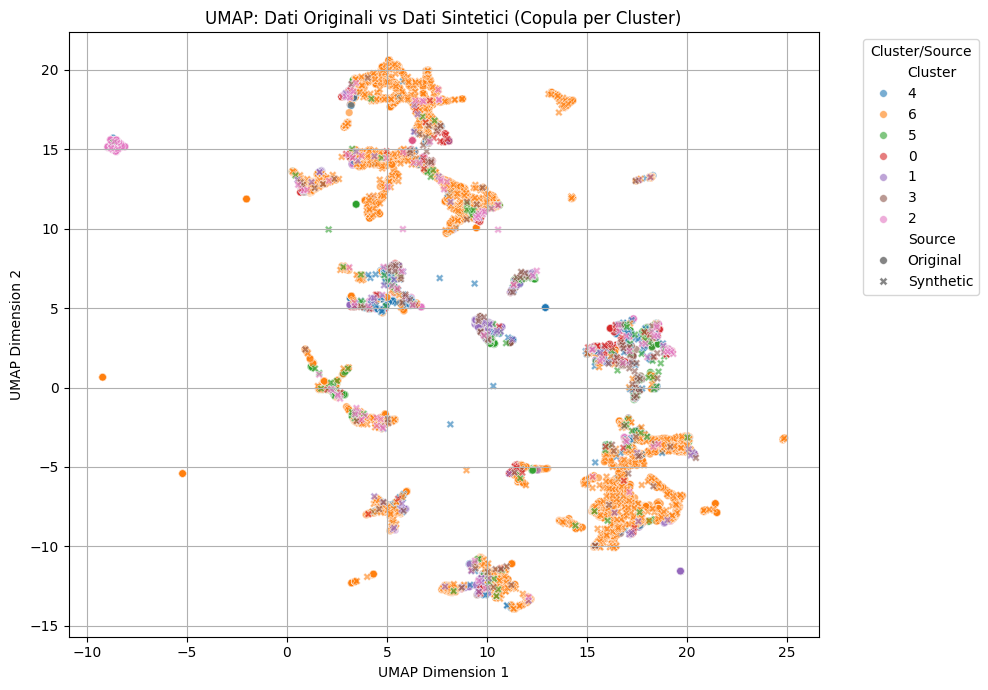

In [45]:
# Visualizzazione UMAP
# Standardizza i dati originali e sintetici
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_originale)
synthetic_scaled = scaler.transform(df_synthetic)

# Esegui UMAP
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
embedding_original = reducer.fit_transform(data_scaled)
embedding_synthetic = reducer.transform(synthetic_scaled)

# Crea un DataFrame per la visualizzazione
df_plot = pd.DataFrame({
    'UMAP1': np.concatenate([embedding_original[:, 0], embedding_synthetic[:, 0]]),
    'UMAP2': np.concatenate([embedding_original[:, 1], embedding_synthetic[:, 1]]),
    'Cluster': np.concatenate([df_originale['Cluster'].astype(str), df_synthetic['Cluster'].astype(str)]),
    'Source': ['Original'] * len(embedding_original) + ['Synthetic'] * len(embedding_synthetic)
})

# Plot UMAP
plt.figure(figsize=(10, 7))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', style='Source', data=df_plot, s=30, alpha=0.6)
plt.title('UMAP: Dati Originali vs Dati Sintetici (Copula per Cluster)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster/Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# **Simple GAN**

Preparazione dataset

In [47]:
import wandb
import torch
import umap
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# a204a7187329b726eaee8c4d1ef3b09f32f54e6b

# PARAMETRI

batch_size = 256
latent_dim = 100
num_epochs = 2500
lr_gen = 0.0005
lr_disc = 0.00001

# Inizializza wandb
wandb.init(
    entity="moranzonisamuele0509-universit-degli-studi-di-milano",
    project="Tirocinio_GAN_cluster_aggiornato",
    name="SimpleGAN_HDBSCAN",
    config={
        "batch_size": batch_size,
        "latent_dim": latent_dim,
        "epochs": num_epochs,
        "lr_generator": lr_gen,
        "lr_discriminator": lr_disc
    }
)

cfg = wandb.config



wandb: Currently logged in as: moranzonisamuele0509 (moranzonisamuele0509-universit-degli-studi-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [48]:
# DATASET

file_path = 'dataset_con_clusters_HDBSCAN.csv'
data = pd.read_csv(file_path)

# Togliamo la colonna 'Cluster' per allenare la GAN semplice
data_no_cluster = data.drop(columns=['Cluster'])

scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data_no_cluster)
data_scaled_df = pd.DataFrame(data_scaled, columns=data_no_cluster.columns)
print(data_scaled_df.head())
real_tensor = torch.tensor(data_scaled, dtype=torch.float32)
dataset = TensorDataset(real_tensor)
train_dl = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)


     Durata  Latitudine  Longitudine  Contemporaneo  CabEnabled_M1  \
0 -0.991952   -0.517451    -0.995794           -1.0           -1.0   
1 -0.991952   -0.517451    -0.995794           -1.0            1.0   
2 -0.991952   -0.517451    -0.995794            1.0            1.0   
3 -0.999959   -0.517451    -0.995794           -1.0           -1.0   
4 -0.999959   -0.517451    -0.995794            1.0            1.0   

   CabEnabled_M8  ERTMS_PiastraSts  HMI_ACPntSts_T2  HMI_ACPntSts_T7  \
0           -1.0              -1.0             -1.0             -1.0   
1           -1.0              -1.0             -1.0             -1.0   
2           -1.0              -1.0             -1.0             -1.0   
3           -1.0              -1.0             -1.0             -1.0   
4           -1.0              -1.0             -1.0             -1.0   

   HMI_DCPntSts_T2  ...  usB2BCilPres_M3  usB2BCilPres_M6  usB2BCilPres_M8  \
0              0.0  ...         0.925926         0.852113         0.

Definizione modelli

In [50]:


# --------------------
# MODELLI
# --------------------
class Generator_Net(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator_Net, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, output_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator_Net(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator_Net, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [52]:
# --------------------
# ISTANZIAZIONE
# --------------------
input_dim = data_no_cluster.shape[1]
print("numero colonne/features ", input_dim)
print("numero righe ", data_no_cluster.shape[0])
G_model = Generator_Net(cfg.latent_dim, output_dim=input_dim)
D_model = Discriminator_Net(input_dim=input_dim)
D_loss_fn = nn.BCELoss()
G_opt = optim.Adam(G_model.parameters(), lr=cfg.lr_generator)
D_opt = optim.Adam(D_model.parameters(), lr=cfg.lr_discriminator)

numero colonne/features  46
numero righe  9975


In [53]:


# TRAINING LOOP
# --------------------
list_losses_real = []
list_losses_fake = []
list_losses_tricked = []

for epoch in range(cfg.epochs):
    for xb_batch in train_dl:
        real_data = xb_batch[0]
        batch_size_curr = real_data.size(0)

        real_labels = torch.ones((batch_size_curr, 1)) * 0.9  # Label smoothing
        fake_labels = torch.zeros((batch_size_curr, 1))

        # Discriminator
        D_opt.zero_grad()
        output_real = D_model(real_data)
        D_real_loss = D_loss_fn(output_real, real_labels)
        D_real_loss.backward()

        noise = torch.rand((batch_size_curr, cfg.latent_dim)) * 2 - 1
        gen_img = G_model(noise)
        output_fake = D_model(gen_img.detach())
        D_fake_loss = D_loss_fn(output_fake, fake_labels)
        D_fake_loss.backward()
        D_opt.step()

        # Generator
        G_opt.zero_grad()
        gen_img = G_model(noise)
        output_trick = D_model(gen_img)
        D_tricked_loss = D_loss_fn(output_trick, real_labels)
        D_tricked_loss.backward()
        G_opt.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D_real_loss={D_real_loss.item():.4f} | D_fake_loss={D_fake_loss.item():.4f} | G_loss={D_tricked_loss.item():.4f}")
        list_losses_real.append(D_real_loss.item())
        list_losses_fake.append(D_fake_loss.item())
        list_losses_tricked.append(D_tricked_loss.item())

        # Log su wandb
        wandb.log({
            "epoch": epoch,
            "D_real_loss": D_real_loss.item(),
            "D_fake_loss": D_fake_loss.item(),
            "G_loss": D_tricked_loss.item()
        })


        

Epoch 0 | D_real_loss=0.6866 | D_fake_loss=0.8970 | G_loss=0.5612
Epoch 100 | D_real_loss=0.6379 | D_fake_loss=0.8676 | G_loss=0.5787
Epoch 200 | D_real_loss=0.7282 | D_fake_loss=0.6538 | G_loss=0.7291
Epoch 300 | D_real_loss=0.7801 | D_fake_loss=0.6350 | G_loss=0.7469
Epoch 400 | D_real_loss=0.7296 | D_fake_loss=0.7087 | G_loss=0.6794
Epoch 500 | D_real_loss=0.7788 | D_fake_loss=0.6214 | G_loss=0.7576
Epoch 600 | D_real_loss=0.8183 | D_fake_loss=0.5996 | G_loss=0.7837
Epoch 700 | D_real_loss=0.7750 | D_fake_loss=0.5733 | G_loss=0.8044
Epoch 800 | D_real_loss=0.7665 | D_fake_loss=0.6068 | G_loss=0.7712
Epoch 900 | D_real_loss=0.7893 | D_fake_loss=0.5614 | G_loss=0.8181
Epoch 1000 | D_real_loss=0.7728 | D_fake_loss=0.6758 | G_loss=0.7149
Epoch 1100 | D_real_loss=0.7647 | D_fake_loss=0.5924 | G_loss=0.7892
Epoch 1200 | D_real_loss=0.7890 | D_fake_loss=0.6098 | G_loss=0.7726
Epoch 1300 | D_real_loss=0.7631 | D_fake_loss=0.5413 | G_loss=0.8475
Epoch 1400 | D_real_loss=0.7895 | D_fake_loss=

In [54]:
# GENERAZIONE DATI
num_righe = 2500
noise = torch.randn((num_righe, cfg.latent_dim))
generated_tensor = G_model(noise)
generated_data = generated_tensor.detach().numpy()

# Inversione della scala per tornare ai valori originali
generated_data_original_scale = scaler.inverse_transform(generated_data)

# ATTENZIONE: usa solo le colonne senza 'Cluster'
columns_senza_cluster = [col for col in data.columns if col != 'Cluster']
df_sintetico = pd.DataFrame(generated_data_original_scale, columns=columns_senza_cluster)

# Nessun campionamento dei cluster qui — GAN semplice = NO cluster

print("Dati generati (scala originale):")
print(df_sintetico.head())

# Log su wandb
wandb.log({"Esempi sintetici": wandb.Table(dataframe=df_sintetico)})

# SALVATAGGIO
output_path = 'outfit_copy/output_gan_semplice/dati_sintetici_generati_gan.csv'
df_sintetico.to_csv(output_path, index=False)
print(f"Dati sintetici salvati in: {output_path}")


Dati generati (scala originale):
      Durata  Latitudine  Longitudine  Contemporaneo  CabEnabled_M1  \
0   1.000000   45.519066     9.210658       1.000000       1.000000   
1   1.000000   45.808525    13.767807       0.000000       0.999997   
2   1.000000   45.812229    13.767951       0.000000       0.999995   
3  15.771752   45.700417    10.568295       0.998518       1.000000   
4   1.017641   45.765316    13.713849       0.000000       0.999996   

   CabEnabled_M8  ERTMS_PiastraSts  HMI_ACPntSts_T2  HMI_ACPntSts_T7  \
0   0.000000e+00          0.012099     8.940697e-08         0.000000   
1   2.980232e-08          1.739631     0.000000e+00         0.000000   
2   5.960464e-08          1.848542     0.000000e+00         0.000000   
3   4.559755e-06          1.535814     7.361472e-04         0.000072   
4   2.086163e-07          1.563843     0.000000e+00         0.000000   

   HMI_DCPntSts_T2  ...  usB2BCilPres_M3  usB2BCilPres_M6  usB2BCilPres_M8  \
0     2.264977e-06  ...      

Metriche di valutazione

In [ ]:
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import jensenshannon
import pandas as pd
import numpy as np

# Carica dataset reale e sintetico
df_real = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")
df_synthetic = pd.read_csv("outfit_copy/output_gan_semplice/dati_sintetici_generati_gan.csv")

# Calcola la matrice di correlazione dei dati sintetici
corr_matrix_synthetic = df_synthetic.corr()
corr_matrix_synthetic.to_csv("outfit_copy/output_gan_semplice/corr_matrix_gan.csv")
print("\n Matrice di correlazione salvata in: outfit_copy/output_gan_semplice/corr_matrix_gan.csv")

# Lista delle feature numeriche in comune
numeric_features = df_real.select_dtypes(include=[np.number]).columns.intersection(df_synthetic.columns)

ks_results = {}
wasserstein_results = {}
mae_stats_results = {}
mutual_info_results = {}
js_results = {}

real_array = df_real[numeric_features].dropna().values
synthetic_array = df_synthetic[numeric_features].dropna().values

# Loop per feature
for feature in numeric_features:
    real_values = df_real[feature].dropna()
    synthetic_values = df_synthetic[feature].dropna()

    # Campionamento per Mutual Info
    if len(real_values) > len(synthetic_values):
        real_values_sampled = np.random.choice(real_values, size=len(synthetic_values), replace=False)
        synthetic_values_sampled = synthetic_values.values
    else:
        real_values_sampled = real_values.values
        synthetic_values_sampled = np.random.choice(synthetic_values, size=len(real_values), replace=False)

    # Test KS
    ks_stat, ks_pvalue = ks_2samp(real_values, synthetic_values)
    ks_results[feature] = {'KS Statistic': ks_stat, 'p-value': ks_pvalue}

    # Distanza di Wasserstein
    wasser = wasserstein_distance(real_values, synthetic_values)
    wasserstein_results[feature] = {'Wasserstein Distance': wasser}

    # MAE su media e varianza
    mean_diff = np.abs(np.mean(real_values) - np.mean(synthetic_values))
    var_diff = np.abs(np.var(real_values) - np.var(synthetic_values))
    mae_stats_results[feature] = {
        'Mean Difference': mean_diff,
        'Variance Difference': var_diff
    }


    # Mutual Information (discretizzata su 20 bin)
    bins = 20
    real_disc = np.digitize(real_values_sampled, bins=np.histogram_bin_edges(real_values, bins=bins))
    synth_disc = np.digitize(synthetic_values_sampled, bins=np.histogram_bin_edges(synthetic_values, bins=bins))
    mi_score = mutual_info_score(real_disc, synth_disc)
    mutual_info_results[feature] = {'Mutual Information': mi_score}

    # Jensen-Shannon Distance
    hist_real, _ = np.histogram(real_values, bins=20, density=True)
    hist_synth, _ = np.histogram(synthetic_values, bins=20, density=True)
    js_dist = jensenshannon(hist_real + 1e-12, hist_synth + 1e-12)  # Avoid div by zero
    js_results[feature] = {'JS Distance': float(js_dist)}


# Converti in DataFrame
ks_df = pd.DataFrame(ks_results).T
wasser_df = pd.DataFrame(wasserstein_results).T
mae_stats_df = pd.DataFrame(mae_stats_results).T
mi_df = pd.DataFrame(mutual_info_results).T
js_df = pd.DataFrame(js_results).T


# Salvataggio CSV
ks_df.to_csv("outfit_copy/output_gan_semplice/ks_comparison_gan.csv")
wasser_df.to_csv("outfit_copy/output_gan_semplice/wasserstein_gan.csv")
mae_stats_df.to_csv("outfit_copy/output_gan_semplice/mae_stats_gan.csv")
mi_df.to_csv("outfit_copy/output_gan_semplice/mutual_info_gan.csv")
js_df.to_csv("outfit_copy/output_gan_semplice/js_distance_gan.csv")


print("\n Risultati KS salvati in: outfit_copy/output_gan_semplice/ks_comparison_gan.csv")
print(" Distanza di Wasserstein salvata in: outfit_copy/output_gan_semplice/wasserstein_gan.csv")
print(" Mae salvata in outfit_copy/output_gan_semplice/mae_stats_gan.csv")
print(" Mutual Information salvata in: outfit_copy/output_gan_semplice/mutual_info_gan.csv")
print(" JS Distance salvata in:outfit_copy/output_gan_semplice//js_distance_gan.csv")



c:\Users\samuele\OneDrive\Desktop\progetto_tesi\gan_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


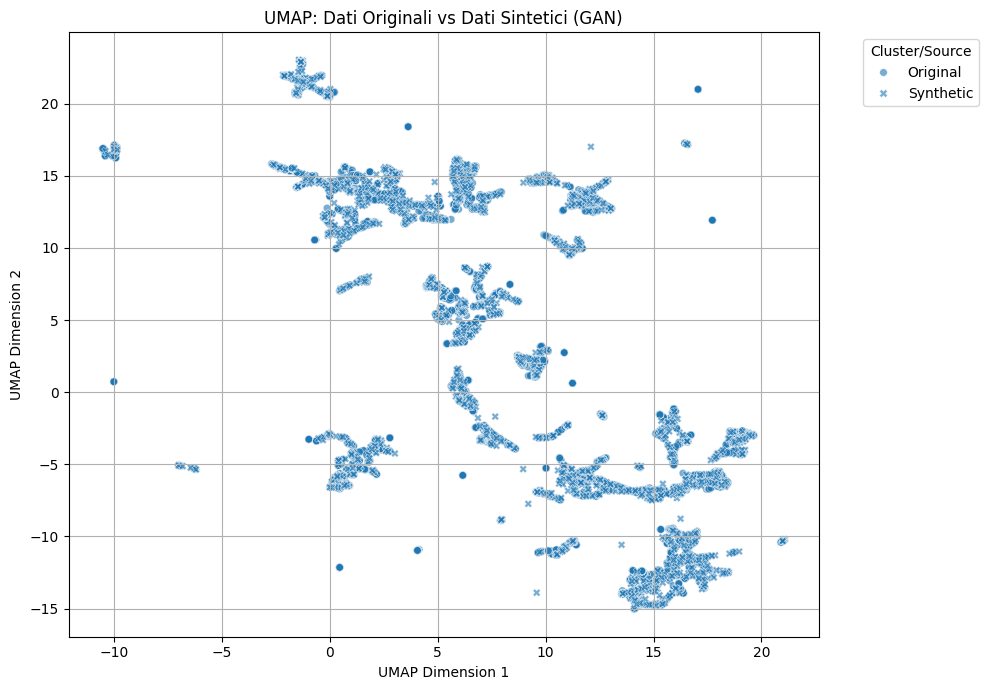

D_loss,▅▁▇▇▅▆▇▇▃▆▅▆▅▅▇▅▇▇▆▇▆█▇▇█
G_loss,▁█▅▄▇▅▆▄▇▇▅▆▄▆▆▄▅▅▅▄▅▅▅▅▆
D_loss,1.39029
G_loss,0.81431


In [80]:
import seaborn as sns 
# Visualizzazione UMAP
# Standardizza i dati originali e sintetici 
scaler_umap = MinMaxScaler()
data_scaled = scaler_umap.fit_transform(data.drop(columns='Cluster'))
synthetic_scaled = scaler_umap.transform(df_sintetico)

# Esegui UMAP
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
embedding_original = reducer.fit_transform(data_scaled)
embedding_synthetic = reducer.transform(synthetic_scaled)

# Crea un DataFrame per la visualizzazione
df_plot = pd.DataFrame({
    'UMAP1': np.concatenate([embedding_original[:, 0], embedding_synthetic[:, 0]]),
    'UMAP2': np.concatenate([embedding_original[:, 1], embedding_synthetic[:, 1]]),
    'Source': ['Original'] * len(embedding_original) + ['Synthetic'] * len(embedding_synthetic)
})

# Plot UMAP
plt.figure(figsize=(10, 7))
sns.scatterplot(x='UMAP1', y='UMAP2', style='Source', data=df_plot, s=30, alpha=0.6)
plt.title('UMAP: Dati Originali vs Dati Sintetici (GAN)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster/Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Fine run wandb
wandb.finish()



# **Conditional GAN**

partiamo dal clustering di cluster k=6 con i 6 gruppi funzionali

In [71]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import wandb

# PARAMETRI
batch_size = 100
latent_dim = 200
num_epochs = 2500
lr_gen = 0.0002
lr_disc = 0.0001

# a204a7187329b726eaee8c4d1ef3b09f32f54e6b
wandb.init(
    entity="moranzonisamuele0509-universit-degli-studi-di-milano",
    project="Tirocinio_GAN_cluster_aggiornato",
    name="ConditionalGAN_HDBScan",
    config={
        "batch_size": batch_size,
        "latent_dim": latent_dim,
        "epochs": num_epochs,
        "lr_generator": lr_gen,
        "lr_discriminator": lr_disc
    }
)
cfg = wandb.config


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


D_fake_loss,█▇▃▃▄▃▂▂▂▁▄▂▂▁▂▂▁▂▄▂▂▂▂▂▂
D_real_loss,▃▁▅▇▅▆█▆▆▇▆▆▇▆▇▇▆▆▆▇▅▆▅▇▅
G_loss,▁▁▅▆▄▆▆▇▆▇▅▇▆█▆▇▇▇▄▇▆▇▆▇▆
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
D_fake_loss,0.6144
D_real_loss,0.7428
G_loss,0.76588
epoch,2400


In [72]:

# Carica dataset clusterizzato
data = pd.read_csv('dataset_con_clusters_HDBSCAN.csv')

# Prepara features e label
features = data.drop(columns=['Cluster'])
labels = data['Cluster'].values.reshape(-1, 1).astype(float)  # float per concatenazione e reshape per rendere labels  array 2D

# Scaling
scaler_nuovo = MinMaxScaler(feature_range=(-1, 1))
features_scaled = scaler_nuovo.fit_transform(features)

# Dataset finale
features_tensor = torch.tensor(features_scaled, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)  # non è necessario scalare qua
dataset = TensorDataset(features_tensor, labels_tensor)
train_dl = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True)

input_dim = features_scaled.shape[1] #numero colonne di features_scaled , dunque numero neuroni primo strato del modello neurale
cond_dim = 1  # una sola colonna per la condizione/label
print(f"Features: {input_dim}, Condizioni: {cond_dim}")


Features: 46, Condizioni: 1


architettura Gan : generatore e discriminatore

In [73]:
# Generatore
class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            #latent dim incrementata da 100 a 200
            nn.Linear(latent_dim + cond_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, output_dim),
            #output_dim:numero di feature del dataset (46)
            nn.Tanh()
)

    def forward(self, noise, cond):
      #ritorna un'insieme di tuple con 46 colonne partendo da il rumore (valori casuali) + label
        x = torch.cat([noise, cond], dim=1)
        return self.model(x)

# Discriminatore : verifica la verosimiglianza dei dati
class Discriminator(nn.Module):
    def __init__(self, input_dim, cond_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim + cond_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid() #valore tra 0 ed 1
        )

    def forward(self, data, cond):
        x = torch.cat([data, cond], dim=1)
        return self.model(x)



istanziazione

In [74]:
#struttura : da 100 dimensione latente + label condizione a output dim
G_model = Generator(cfg.latent_dim, cond_dim, input_dim)
D_model = Discriminator(input_dim, cond_dim)
D_loss_fn = nn.BCELoss()
G_opt = optim.Adam(G_model.parameters(), lr=cfg.lr_generator)
D_opt = optim.Adam(D_model.parameters(), lr=cfg.lr_discriminator)


training

In [75]:
for epoch in range(cfg.epochs):
    for real_data, cond in train_dl:
        batch_size_curr = real_data.size(0)
        real_labels = torch.ones((batch_size_curr, 1)) * 0.9
        fake_labels = torch.zeros((batch_size_curr, 1))

        # --------------------
        # TRAIN DISCRIMINATORE
        # --------------------
        D_opt.zero_grad()
        output_real = D_model(real_data, cond)
        D_real_loss = D_loss_fn(output_real, real_labels)
        #n.b: torch.rand già genera valori tra o ed 1 , vengono scalati a dominio appartenente a [-1,1]
        noise = torch.rand((batch_size_curr, cfg.latent_dim)) * 2 - 1
        fake_data = G_model(noise, cond)
        output_fake = D_model(fake_data.detach(), cond)
        D_fake_loss = D_loss_fn(output_fake, fake_labels)

        D_loss = D_real_loss + D_fake_loss
        D_loss.backward()
        D_opt.step()

        # ----------------
        # TRAIN GENERATORE
        # ----------------
        G_opt.zero_grad()
        output_trick = D_model(fake_data, cond)
        G_loss = D_loss_fn(output_trick, real_labels)
        G_loss.backward()
        G_opt.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D_loss={D_loss.item():.4f}, G_loss={G_loss.item():.4f}")
        wandb.log({"D_loss": D_loss.item(), "G_loss": G_loss.item()})
# **Confronto risultati reali e sintetici**

Epoch 0: D_loss=1.3357, G_loss=0.7051
Epoch 100: D_loss=1.2624, G_loss=0.8688
Epoch 200: D_loss=1.3764, G_loss=0.7899
Epoch 300: D_loss=1.3713, G_loss=0.7858
Epoch 400: D_loss=1.3307, G_loss=0.8430
Epoch 500: D_loss=1.3482, G_loss=0.7968
Epoch 600: D_loss=1.3668, G_loss=0.8294
Epoch 700: D_loss=1.3822, G_loss=0.7783
Epoch 800: D_loss=1.2990, G_loss=0.8372
Epoch 900: D_loss=1.3612, G_loss=0.8566
Epoch 1000: D_loss=1.3447, G_loss=0.7995
Epoch 1100: D_loss=1.3547, G_loss=0.8284
Epoch 1200: D_loss=1.3417, G_loss=0.7866
Epoch 1300: D_loss=1.3338, G_loss=0.8108
Epoch 1400: D_loss=1.3692, G_loss=0.8127
Epoch 1500: D_loss=1.3284, G_loss=0.7759
Epoch 1600: D_loss=1.3667, G_loss=0.7901
Epoch 1700: D_loss=1.3671, G_loss=0.8081
Epoch 1800: D_loss=1.3636, G_loss=0.7997
Epoch 1900: D_loss=1.3695, G_loss=0.7824
Epoch 2000: D_loss=1.3606, G_loss=0.7954
Epoch 2100: D_loss=1.3927, G_loss=0.8067
Epoch 2200: D_loss=1.3715, G_loss=0.8005
Epoch 2300: D_loss=1.3715, G_loss=0.7878
Epoch 2400: D_loss=1.3903, G

Generazione dati

In [96]:
num_righe = 2500
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()

# Generazione dati sintetici (1000 righe)
noise = torch.rand((num_righe, cfg.latent_dim)) * 2 - 1
cluster_ids = data['Cluster'].sample(n=num_righe, random_state=42).values
cluster_cond = torch.tensor(cluster_ids, dtype=torch.float32).reshape(-1, 1)

with torch.no_grad():
    synthetic_scaled = G_model(noise, cluster_cond)

synthetic_scaled_np = synthetic_scaled.cpu().numpy()
synthetic_original = scaler_nuovo.inverse_transform(synthetic_scaled_np)
df_sintetico = pd.DataFrame(synthetic_original, columns=data.columns[:-1])

df_sintetico['Cluster'] = cluster_ids


# Log su wandb
#wandb.log({"Esempi sintetici": wandb.Table(dataframe=df_sintetico)})

# Salva i dati sintetici
output_path = 'outfit_copy/output_gan_condizionale/dati_sintetici_generati_cgan.csv'
df_sintetico.to_csv(output_path, index=False)
print(f"\n Dati sintetici salvati in: {output_path}")



 Dati sintetici salvati in: outfit_copy/output_gan_condizionale/dati_sintetici_generati_cgan.csv


Metriche di valutazione

In [7]:
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import jensenshannon
import pandas as pd
import numpy as np

# Carica dataset reale e sintetico
df_real = pd.read_csv("dataset_con_clusters_HDBSCAN.csv")
df_synthetic = pd.read_csv("outfit_copy/output_gan_condizionale/dati_sintetici_generati_cgan.csv")

# Calcola la matrice di correlazione dei dati sintetici
"""cluster_syn = df_synthetic['Cluster']
df_syn_no_cluster = df_synthetic.drop(columns=['Cluster'])
corr_matrix_synthetic = df_syn_no_cluster.corr()
corr_matrix_synthetic['Cluster'] = cluster_syn"""

corr_matrix_synthetic = df_synthetic.corr()
corr_matrix_synthetic.to_csv("outfit_copy/output_gan_condizionale/corr_matrix_cgan.csv")
print("\n Matrice di correlazione salvata in: output_copula_semplice/corr_matrix_cgan.csv")

# Lista delle feature numeriche in comune
numeric_features = df_real.select_dtypes(include=[np.number]).columns.intersection(df_synthetic.columns)

ks_results = {}
wasserstein_results = {}
mae_stats_results = {}
mutual_info_results = {}
js_results = {}

real_array = df_real[numeric_features].dropna().values
synthetic_array = df_synthetic[numeric_features].dropna().values

# Loop per feature
for feature in numeric_features:
    real_values = df_real[feature].dropna()
    synthetic_values = df_synthetic[feature].dropna()

    # Campionamento per Mutual Info
    if len(real_values) > len(synthetic_values):
        real_values_sampled = np.random.choice(real_values, size=len(synthetic_values), replace=False)
        synthetic_values_sampled = synthetic_values.values
    else:
        real_values_sampled = real_values.values
        synthetic_values_sampled = np.random.choice(synthetic_values, size=len(real_values), replace=False)

    # Test KS
    ks_stat, ks_pvalue = ks_2samp(real_values, synthetic_values)
    ks_results[feature] = {'KS Statistic': ks_stat, 'p-value': ks_pvalue}

    # Distanza di Wasserstein
    wasser = wasserstein_distance(real_values, synthetic_values)
    wasserstein_results[feature] = {'Wasserstein Distance': wasser}

    # MAE su media e varianza : np.mean fa la media per ogni colonna esistente
    mean_diff = np.abs(np.mean(real_values) - np.mean(synthetic_values))
    var_diff = np.abs(np.var(real_values) - np.var(synthetic_values))
    mae_stats_results[feature] = {
        'Mean Difference': mean_diff,
        'Variance Difference': var_diff
    }


    # Mutual Information (discretizzata su 20 bin)
    bins = 20
    real_disc = np.digitize(real_values_sampled, bins=np.histogram_bin_edges(real_values, bins=bins))
    synth_disc = np.digitize(synthetic_values_sampled, bins=np.histogram_bin_edges(synthetic_values, bins=bins))
    mi_score = mutual_info_score(real_disc, synth_disc)
    mutual_info_results[feature] = {'Mutual Information': mi_score}

    # Jensen-Shannon Distance
    hist_real, _ = np.histogram(real_values, bins=20, density=True)
    hist_synth, _ = np.histogram(synthetic_values, bins=20, density=True)
    js_dist = jensenshannon(hist_real + 1e-12, hist_synth + 1e-12)  # Avoid div by zero
    js_results[feature] = {'JS Distance': float(js_dist)}


# Converti in DataFrame
ks_df = pd.DataFrame(ks_results).T
wasser_df = pd.DataFrame(wasserstein_results).T
mae_stats_df = pd.DataFrame(mae_stats_results).T
mi_df = pd.DataFrame(mutual_info_results).T
js_df = pd.DataFrame(js_results).T


# Salvataggio CSV
ks_df.to_csv("outfit_copy/output_gan_condizionale/ks_comparison_cgan.csv")
wasser_df.to_csv("outfit_copy/output_gan_condizionale/wasserstein_cgan.csv")
mae_stats_df.to_csv("outfit_copy/output_gan_condizionale/mae_stats_cgan.csv")
mi_df.to_csv("outfit_copy/output_gan_condizionale/mutual_info_cgan.csv")
js_df.to_csv("outfit_copy/output_gan_condizionale/js_distance_cgan.csv")


print("\n Risultati KS salvati in: output_gan_condizionale/ks_comparison_cgan.csv")
print(" Distanza di Wasserstein salvata in: output_gan_condizionale/wasserstein_cgan.csv")
print(f" Mae salvata in output_gan_condizionale/mae_stats_cgan.csv")
print(" Mutual Information salvata in: output_gan_condizionale/mutual_info_cgan.csv")
print(" JS Distance salvata in: output_gan_condizionale/js_distance_cgan.csv")



 Matrice di correlazione salvata in: output_copula_semplice/corr_matrix_cgan.csv

 Risultati KS salvati in: output_gan_condizionale/ks_comparison_cgan.csv
 Distanza di Wasserstein salvata in: output_gan_condizionale/wasserstein_cgan.csv
 Mae salvata in output_gan_condizionale/mae_stats_cgan.csv
 Mutual Information salvata in: output_gan_condizionale/mutual_info_cgan.csv
 JS Distance salvata in: output_gan_condizionale/js_distance_cgan.csv


Visualizzazione UMAP

c:\Users\samuele\OneDrive\Desktop\progetto_tesi\gan_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NameError: name 'wandb' is not defined

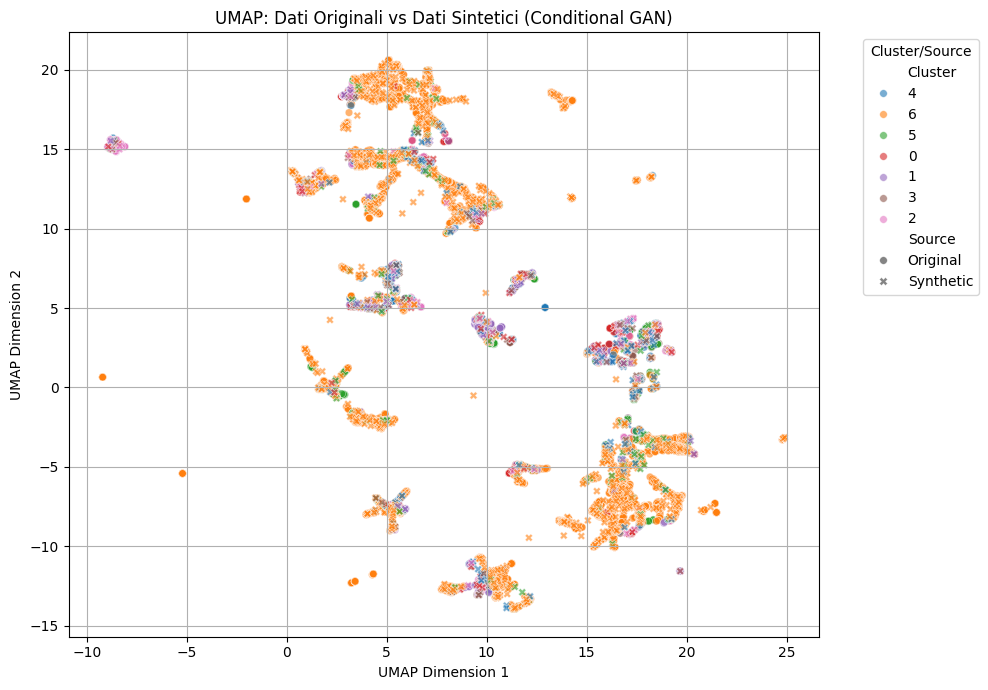

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import umap.umap_ as umap


# Visualizzazione UMAP
scaler_umap = MinMaxScaler()


data_scaled = scaler_umap.fit_transform(df_real[numeric_features])
synthetic_scaled = scaler_umap.transform(df_synthetic[numeric_features])

reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2, random_state=42)
embedding_original = reducer.fit_transform(data_scaled)
embedding_synthetic = reducer.transform(synthetic_scaled)

df_plot = pd.DataFrame({
    'UMAP1': np.concatenate([embedding_original[:, 0], embedding_synthetic[:, 0]]),
    'UMAP2': np.concatenate([embedding_original[:, 1], embedding_synthetic[:, 1]]),
    'Cluster': np.concatenate([df_real['Cluster'].astype(str), df_synthetic['Cluster'].astype(str)]),
    'Source': ['Original'] * len(embedding_original) + ['Synthetic'] * len(embedding_synthetic)
})

plt.figure(figsize=(10, 7))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', style='Source', data=df_plot, s=30, alpha=0.6)
plt.title('UMAP: Dati Originali vs Dati Sintetici (Conditional GAN)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster/Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
wandb.log({"UMAP_plot": wandb.Image(plt)})
plt.show()

# Fine run wandb
wandb.finish()


# **Confronto risultati**

calcolo differenza di matrice correlazione tra matrice originale e matrice di ogni modello 

In [9]:
# Calcola differenze di correlazione una per una
corr_matrix_original = pd.read_csv('outfit_copy\corr_matrix_original.csv', index_col=0)

# 1. Simple Copula
corr_matrix_copula = pd.read_csv('outfit_copy/output_copula_semplice/corr_matrix_copula.csv', index_col=0)
corr_diff_copula = np.abs(corr_matrix_original - corr_matrix_copula)
corr_diff_copula_df = pd.DataFrame(corr_diff_copula, index=corr_matrix_original.index, columns=corr_matrix_original.columns)
corr_diff_copula_df.to_csv('outfit_copy/output_copula_semplice/corr_diff_copula.csv')
print(" Differenza matrice di correlazione salvata in: outfit_copy/output_copula_semplice/corr_diff_copula.csv")
corr_diff_copula_array = corr_diff_copula.to_numpy()
corr_diff_copula_values = corr_diff_copula_array[np.triu_indices_from(corr_diff_copula_array, k=1)]


# 2. Copula per Cluster
corr_matrix_copula_clusters = pd.read_csv('outfit_copy/output_copula_clusters/corr_matrix_copula_clusters.csv', index_col=0)
corr_diff_copula_clusters = np.abs(corr_matrix_original - corr_matrix_copula_clusters)
corr_diff_copula_clusters_df = pd.DataFrame(corr_diff_copula_clusters, index=corr_matrix_original.index, columns=corr_matrix_original.columns)
corr_diff_copula_clusters_df.to_csv('outfit_copy/output_copula_clusters/corr_diff_copula_clusters.csv')
print(" Differenza matrice di correlazione salvata in: output_copula_clusters/corr_diff_copula_clusters.csv")
corr_diff_copula_clusters_array = corr_diff_copula_clusters.to_numpy()
corr_diff_copula_clusters_values = corr_diff_copula_clusters_array[np.triu_indices_from(corr_diff_copula_clusters_array, k=1)]


# 3. Simple GAN
corr_matrix_gan = pd.read_csv('outfit_copy/output_gan_semplice/corr_matrix_gan.csv', index_col=0)
corr_diff_gan = np.abs(corr_matrix_original - corr_matrix_gan)
corr_diff_gan_df = pd.DataFrame(corr_diff_gan, index=corr_matrix_original.index, columns=corr_matrix_original.columns)
corr_diff_gan_df.to_csv('outfit_copy/output_gan_semplice/corr_diff_gan.csv')
print(" Differenza matrice di correlazione salvata in: output_gan_semplice/corr_diff_gan.csv")
corr_diff_gan_array = corr_diff_gan.to_numpy()
corr_diff_gan_values = corr_diff_gan_array[np.triu_indices_from(corr_diff_gan_array, k=1)]


# 4. Conditional GAN
corr_matrix_cgan = pd.read_csv('outfit_copy/output_gan_condizionale/corr_matrix_cgan.csv', index_col=0)
corr_diff_cgan = np.abs(corr_matrix_original - corr_matrix_cgan)
corr_diff_cgan_df = pd.DataFrame(corr_diff_cgan, index=corr_matrix_original.index, columns=corr_matrix_original.columns)
corr_diff_cgan_df.to_csv('outfit_copy/output_gan_condizionale/corr_diff_cgan.csv')
print(" Differenza matrice di correlazione salvata in: output_gan_condizionale/corr_diff_cgan.csv")
corr_diff_cgan_array = corr_diff_cgan.to_numpy()
corr_diff_cgan_values = corr_diff_cgan_array[np.triu_indices_from(corr_diff_cgan_array, k=1)]


 Differenza matrice di correlazione salvata in: outfit_copy/output_copula_semplice/corr_diff_copula.csv
 Differenza matrice di correlazione salvata in: output_copula_clusters/corr_diff_copula_clusters.csv
 Differenza matrice di correlazione salvata in: output_gan_semplice/corr_diff_gan.csv
 Differenza matrice di correlazione salvata in: output_gan_condizionale/corr_diff_cgan.csv


confronto modelli condizionali : copula con clusters e gan condizionale 


▶ Analizzo modello: copula_clusters

▶ Analizzo modello: gan_condizionale

 Tabella salvata in: outfit_copy/output_comparison/comparison_summary_filtered.csv
             Model  Mean Corr Diff  Mean KS Statistic  Mean KS p-value  Mean Wasserstein  Mean Mutual Info  Mean JS Distance   Mean Diff  Variance Diff
Copula per Cluster        0.095903           0.197147         0.021285       1356.533374          0.032581          0.614504 1346.007614   5.788186e+10
   Conditional GAN        0.030879           0.206802         0.021277         15.593589          0.043362          0.186243    6.883624   2.190882e+05


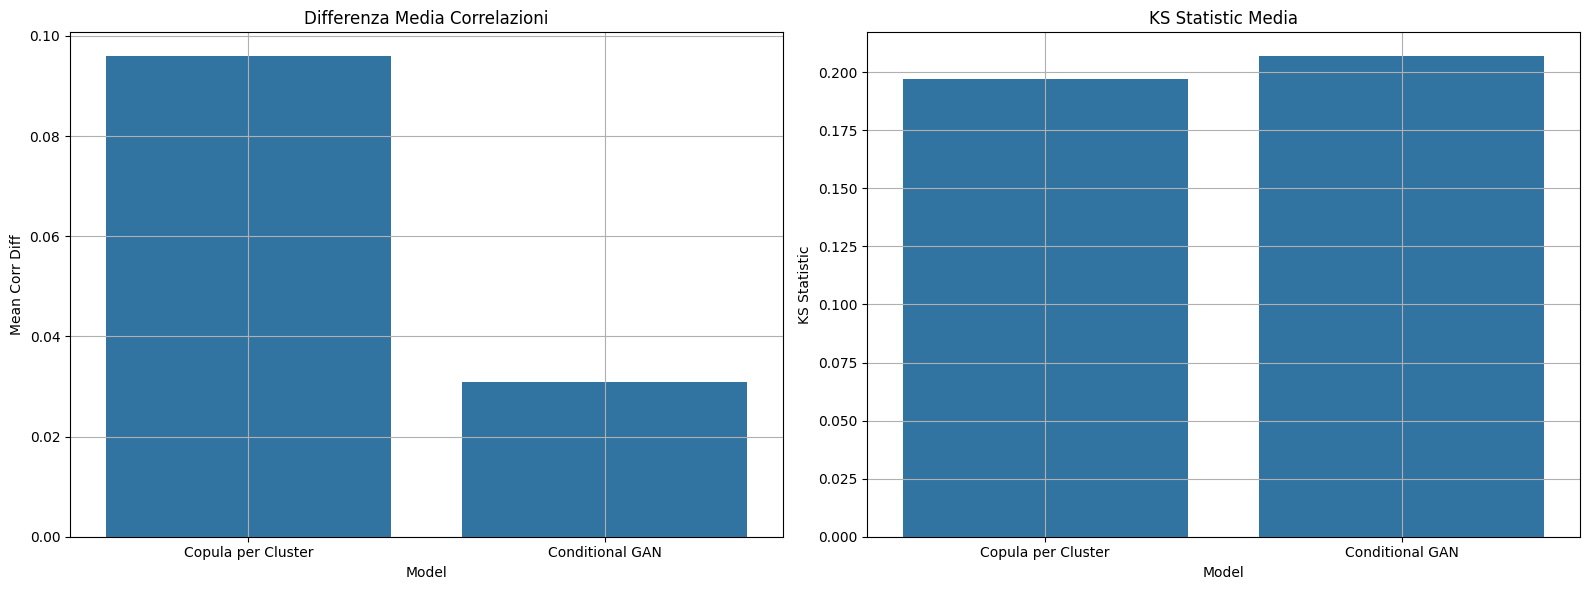


 Grafico salvato in: outfit_copy/output_comparison/comparison_plot_filtered.png


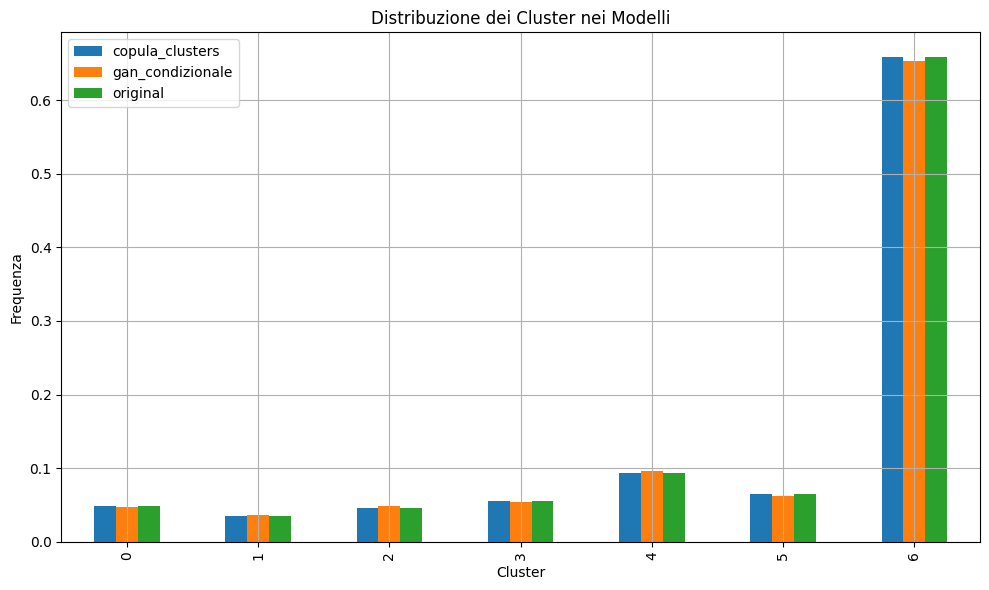


 Distribuzione cluster salvata in: outfit_copy/output_comparison/cluster_distribution_plot_filtered.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === MODELLI ===
models = ['copula_clusters', 'gan_condizionale']
model_labels = ['Copula per Cluster', 'Conditional GAN']
model_suffixes = ['copula_clusters', 'cgan']
model_paths = ['outfit_copy/output_copula_clusters', 'outfit_copy/output_gan_condizionale']

# === PATH BASE ===
os.makedirs('outfit_copy/output_comparison', exist_ok=True)

# === MATRICE DI CORRELAZIONE ORIGINALE ===
corr_matrix_original = pd.read_csv('corr_matrix_original.csv', index_col=0)

# === METRICHE ===
corr_diff_means = {}
ks_stat_means = {}
ks_pvalue_means = {}
wasserstein_means = {}
mutual_info_means = {}
js_means = {}
mean_diff_means = {}
var_diff_means = {}

"""
# === Funzione per allineare colonne ===
def align_columns(reference_df, target_df):
    common_cols = reference_df.columns.intersection(target_df.columns)
    return target_df[common_cols], reference_df[common_cols]
"""

# === ANALISI PER MODELLO ===
for model, suffix, path in zip(models, model_suffixes, model_paths):
    print(f"\n▶ Analizzo modello: {model}")

    # --- Correlazione ---
    corr_file = f'{path}/corr_matrix_{suffix}.csv'
    corr_matrix = pd.read_csv(corr_file, index_col=0)
    corr_diff = np.abs(corr_matrix_original - corr_matrix)
    corr_diff_array = corr_diff.to_numpy()
    corr_diff_values = corr_diff_array[np.triu_indices_from(corr_diff_array, k=1)]
    corr_diff_means[model] = np.mean(corr_diff_values)

    # --- KS ---
    ks_df = pd.read_csv(f'{path}/ks_comparison_{suffix}.csv', index_col=0)
    ks_stat_means[model] = ks_df['KS Statistic'].mean()
    ks_pvalue_means[model] = ks_df['p-value'].mean()

    # --- Wasserstein ---
    wasserstein_df = pd.read_csv(f'{path}/wasserstein_{suffix}.csv', index_col=0)
    wasserstein_means[model] = wasserstein_df['Wasserstein Distance'].mean()

    # --- Mutual Info ---
    mi_df = pd.read_csv(f'{path}/mutual_info_{suffix}.csv', index_col=0)
    mutual_info_means[model] = mi_df['Mutual Information'].mean()

    # --- Jensen-Shannon ---
    js_df = pd.read_csv(f'{path}/js_distance_{suffix}.csv', index_col=0)
    js_means[model] = js_df['JS Distance'].mean()

    # --- Mean/Var Difference ---
    stats_df = pd.read_csv(f'{path}/mae_stats_{suffix}.csv', index_col=0)
    mean_diff_means[model] = stats_df['Mean Difference'].mean()
    var_diff_means[model] = stats_df['Variance Difference'].mean()

# === TABELLONE FINALE ===
comparison_df = pd.DataFrame({
    'Model': model_labels,
    'Mean Corr Diff': [corr_diff_means[m] for m in models],
    'Mean KS Statistic': [ks_stat_means[m] for m in models],
    'Mean KS p-value': [ks_pvalue_means[m] for m in models],
    'Mean Wasserstein': [wasserstein_means[m] for m in models],
    'Mean Mutual Info': [mutual_info_means[m] for m in models],
    'Mean JS Distance': [js_means[m] for m in models],
    'Mean Diff': [mean_diff_means[m] for m in models],
    'Variance Diff': [var_diff_means[m] for m in models]
})

comparison_df.to_csv('outfit_copy/output_comparison/comparison_summary_filtered.csv', index=False)
print("\n Tabella salvata in: outfit_copy/output_comparison/comparison_summary_filtered.csv")
print(comparison_df.to_string(index=False))

# === GRAFICO ===
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Mean Corr Diff', data=comparison_df)
plt.title('Differenza Media Correlazioni')
plt.ylabel('Mean Corr Diff')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Mean KS Statistic', data=comparison_df)
plt.title('KS Statistic Media')
plt.ylabel('KS Statistic')
plt.grid(True)

plt.tight_layout()
plt.savefig('outfit_copy/output_comparison/comparison_plot_filtered.png')
plt.show()
print("\n Grafico salvato in: outfit_copy/output_comparison/comparison_plot_filtered.png")

# === DISTRIBUZIONE CLUSTER ===
data = pd.read_csv('dataset_con_clusters_HDBSCAN.csv')
cluster_dist = {}
for model, suffix, path in zip(models, model_suffixes, model_paths):
    df_synth = pd.read_csv(f'{path}/dati_sintetici_generati_{suffix}.csv')
    if 'Cluster' in df_synth.columns:
        cluster_dist[model] = df_synth['Cluster'].value_counts(normalize=True).sort_index()
cluster_dist['original'] = data['Cluster'].value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame(cluster_dist).fillna(0)
dist_df.to_csv('outfit_copy/output_comparison/cluster_distribution_filtered.csv')

dist_df.plot(kind='bar', figsize=(10, 6))
plt.title('Distribuzione dei Cluster nei Modelli')
plt.xlabel('Cluster')
plt.ylabel('Frequenza')
plt.grid(True)
plt.tight_layout()
plt.savefig('outfit_copy/output_comparison/cluster_distribution_plot_filtered.png')
plt.show()
print("\n Distribuzione cluster salvata in: outfit_copy/output_comparison/cluster_distribution_plot_filtered.png")


confronto cluster per cluster dei 2 modelli condizionali

In [11]:
import os
import numpy as np
import pandas as pd

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import mutual_info_score
from scipy.spatial.distance import jensenshannon

# =================== PATH INPUT ===================
REAL_PATH = 'dataset_con_clusters_HDBSCAN.csv'
SYNTH_PATHS = {
    'cgan': 'outfit_copy/output_gan_condizionale/dati_sintetici_generati_cgan.csv',
    'copula_clusters': 'outfit_copy/output_copula_clusters/dati_sintetici_generati_copula_clusters.csv'
}

# =================== LOAD ===================
df_real = pd.read_csv(REAL_PATH)
assert 'Cluster' in df_real.columns, "Nel dataset reale manca la colonna 'Cluster'."

df_cgan = pd.read_csv(SYNTH_PATHS['cgan'])
df_cop = pd.read_csv(SYNTH_PATHS['copula_clusters'])
for name, df in [('cgan', df_cgan), ('copula_clusters', df_cop)]:
    assert 'Cluster' in df.columns, f"Nel sintetico {name} manca la colonna 'Cluster'."

# Solo feature numeriche comuni (escludo Cluster)
num_real = df_real.select_dtypes(include=[np.number]).columns.tolist()
if 'Cluster' in num_real: num_real.remove('Cluster')

num_cgan = df_cgan.select_dtypes(include=[np.number]).columns.tolist()
if 'Cluster' in num_cgan: num_cgan.remove('Cluster')

num_cop = df_cop.select_dtypes(include=[np.number]).columns.tolist()
if 'Cluster' in num_cop: num_cop.remove('Cluster')

cols_cgan = sorted(list(set(num_real).intersection(set(num_cgan))))
cols_cop  = sorted(list(set(num_real).intersection(set(num_cop))))

clusters = sorted(df_real['Cluster'].dropna().unique().tolist())

# =================== UTILS ===================
def per_feature_metrics(real_vals, synth_vals, bins=20):
    r = pd.Series(real_vals).dropna().values
    s = pd.Series(synth_vals).dropna().values
    out = {
        'KS Statistic': np.nan, 'p-value': np.nan,
        'Wasserstein Distance': np.nan,
        'JS Distance': np.nan,
        'Mean Difference': np.nan,
        'Variance Difference': np.nan
    }
    if len(r) < 2 or len(s) < 2:
        return out

    # KS
    ks_stat, ks_p = ks_2samp(r, s)
    out['KS Statistic'] = float(ks_stat)
    out['p-value'] = float(ks_p)

    # Wasserstein
    out['Wasserstein Distance'] = float(wasserstein_distance(r, s))


    # JS distance (densità sugli stessi bin)
    hr, _ = np.histogram(r,  density=True)
    hs, _ = np.histogram(s,  density=True)
    hr = hr + 1e-12
    hs = hs + 1e-12
    out['JS Distance'] = float(jensenshannon(hr, hs))

    # Mean/Var diff
    out['Mean Difference'] = float(abs(np.mean(r) - np.mean(s)))
    out['Variance Difference'] = float(abs(np.var(r) - np.var(s)))
    return out

def corr_diff_mean(df_r, df_s, cols):
    if len(df_r) < 3 or len(df_s) < 3 or len(cols) < 2:
        print(f"corr_diff_mean: Saltato per df_r={len(df_r)}, df_s={len(df_s)}, cols={len(cols)}")
        return np.nan
    # Rimuovi righe con NaN
    df_r_clean = df_r[cols].dropna()
    df_s_clean = df_s[cols].dropna()
    if len(df_r_clean) < 3 or len(df_s_clean) < 3:
        print(f"corr_diff_mean: Troppe righe rimosse dopo dropna, df_r_clean={len(df_r_clean)}, df_s_clean={len(df_s_clean)}")
        return np.nan
    # Filtra feature con varianza sufficiente
    valid_cols = [col for col in cols if df_r_clean[col].var() > 1e-10 and df_s_clean[col].var() > 1e-10]
    if len(valid_cols) < 2:
        print(f"corr_diff_mean: Feature valide insufficienti dopo filtro varianza: {valid_cols}")
        return np.nan
    # Calcola correlazioni
    cr = df_r_clean[valid_cols].corr().to_numpy()
    cs = df_s_clean[valid_cols].corr().to_numpy()
    # Sostituisci NaN con 0 nelle matrici di correlazione
    cr = np.nan_to_num(cr, nan=0.0)
    cs = np.nan_to_num(cs, nan=0.0)
    diff = np.abs(cr - cs)
    iu = np.triu_indices_from(diff, k=1)
    return float(np.mean(diff[iu]))

def eval_model_per_cluster(model_key, df_syn, cols_model, base_out_dir):
    """
    Calcola e salva metriche per cluster per un modello (cgan o copula_clusters).
    Salvataggi in: base_out_dir/metriche_per_cluster/cluster_{ID}/...
    Ritorna una summary per-cluster (DataFrame).
    """
    summary_rows = []
    out_root = os.path.join(base_out_dir, 'metriche_per_cluster')
    os.makedirs(out_root, exist_ok=True)

    for c in clusters:
        real_c = df_real[df_real['Cluster'] == c]
        synth_c = df_syn[df_syn['Cluster'] == c]
        if len(real_c) < 3 or len(synth_c) < 3:
            continue

        cols = cols_model  # comuni e numerici
        if not cols:
            continue

        ks_rows, w_rows , js_rows, stats_rows = [], [], [], []
        for col in cols:
            m = per_feature_metrics(real_c[col], synth_c[col], bins=20)
            ks_rows.append([col, m['KS Statistic'], m['p-value']])
            w_rows.append([col, m['Wasserstein Distance']])
            js_rows.append([col, m['JS Distance']])
            stats_rows.append([col, m['Mean Difference'], m['Variance Difference']])

        ks_df    = pd.DataFrame(ks_rows, columns=['Feature','KS Statistic','p-value']).set_index('Feature')
        w_df     = pd.DataFrame(w_rows, columns=['Feature','Wasserstein Distance']).set_index('Feature')
        js_df    = pd.DataFrame(js_rows, columns=['Feature','JS Distance']).set_index('Feature')
        stats_df = pd.DataFrame(stats_rows, columns=['Feature','Mean Difference','Variance Difference']).set_index('Feature')

        # Corr-diff media nel cluster
        corr_diff = corr_diff_mean(real_c, synth_c, cols)

        # Cartella del cluster per il modello
        cluster_dir = os.path.join(out_root, f'cluster_{c}')
        os.makedirs(cluster_dir, exist_ok=True)

        # Salvataggi simmetrici al tuo naming
        # (uso suffix coerenti: cgan / copula_clusters)
        suffix = 'cgan' if model_key == 'cgan' else 'copula_clusters'
        ks_df.to_csv(os.path.join(cluster_dir, f'ks_comparison_{suffix}.csv'))
        w_df.to_csv(os.path.join(cluster_dir, f'wasserstein_{suffix}.csv'))
        js_df.to_csv(os.path.join(cluster_dir, f'js_distance_{suffix}.csv'))
        stats_df.to_csv(os.path.join(cluster_dir, f'mae_stats_{suffix}.csv'))

        # Corr-diff: salvo un csv con il valore scalare
        pd.DataFrame({'Mean Corr Diff':[corr_diff]}).to_csv(
            os.path.join(cluster_dir, f'corr_diff_{suffix}.csv'), index=False
        )

        # Riga di summary
        summary_rows.append({
            'Model': model_key,
            'Cluster': c,
            'n_real': len(real_c),
            'n_synth': len(synth_c),
            'Mean Corr Diff': corr_diff,
            'Mean KS Statistic': float(ks_df['KS Statistic'].mean()),
            'Mean KS p-value': float(ks_df['p-value'].mean()),
            'Mean Wasserstein': float(w_df['Wasserstein Distance'].mean()),
            'Mean JS Distance': float(js_df['JS Distance'].mean()),
            'Mean Diff': float(stats_df['Mean Difference'].mean()),
            'Variance Diff': float(stats_df['Variance Difference'].mean()),
        })

    summary_df = pd.DataFrame(summary_rows)
    # Salva summary per modello
    model_label = 'gan_condizionale' if model_key == 'cgan' else 'copula_clusters'
    summary_path = os.path.join(out_root, f'summary_per_cluster_{model_label}.csv')
    summary_df.to_csv(summary_path, index=False)
    print(f" Summary per-cluster salvata: {summary_path}")
    return summary_df

# =================== ESECUZIONE PER MODELLO ===================
summary_cgan = eval_model_per_cluster(
    model_key='cgan',
    df_syn=df_cgan,
    cols_model=cols_cgan,
    base_out_dir='outfit_copy/output_gan_condizionale'
)

summary_cop = eval_model_per_cluster(
    model_key='copula_clusters',
    df_syn=df_cop,
    cols_model=cols_cop,
    base_out_dir='outfit_copy/output_copula_clusters'
)

# =================== MERGE SUMMARY (opzionale) ===================
summary_all = pd.concat([summary_cgan.assign(Model='Conditional GAN'),
                         summary_cop.assign(Model='Copula per Cluster')], ignore_index=True)
summary_all = summary_all[['Model','Cluster','n_real','n_synth',
                           'Mean Corr Diff','Mean KS Statistic','Mean KS p-value',
                           'Mean Wasserstein','Mean JS Distance',
                           'Mean Diff','Variance Diff']].sort_values(['Cluster','Model'])

out_merged = 'outfit_copy/output_comparison_per_cluster_summary.csv'
os.makedirs(os.path.dirname(out_merged), exist_ok=True)
summary_all.to_csv(out_merged, index=False)
print(f" Confronto per-cluster (entrambi i modelli) salvato in: {out_merged}")
print(summary_all.head(20).to_string(index=False))


 Summary per-cluster salvata: outfit_copy/output_gan_condizionale\metriche_per_cluster\summary_per_cluster_gan_condizionale.csv


c:\Users\samuele\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\spatial\distance.py:1391: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(js / 2.0)


 Summary per-cluster salvata: outfit_copy/output_copula_clusters\metriche_per_cluster\summary_per_cluster_copula_clusters.csv
 Confronto per-cluster (entrambi i modelli) salvato in: outfit_copy/output_comparison_per_cluster_summary.csv
             Model  Cluster  n_real  n_synth  Mean Corr Diff  Mean KS Statistic  Mean KS p-value  Mean Wasserstein  Mean JS Distance   Mean Diff  Variance Diff
   Conditional GAN        0     482      119        0.181178           0.284166     8.741778e-02         40.494699          0.265100   36.383108   2.567960e+05
Copula per Cluster        0     482      120        0.085250           0.269517     4.892871e-02         24.165842          0.549567   14.573933   5.525899e+05
   Conditional GAN        1     344       90        0.168402           0.299951     9.048454e-02         46.702177          0.252589   39.111526   1.990487e+06
Copula per Cluster        1     344       86        0.089050           0.283809     5.006876e-02         58.200850          

confronto tra i 4 modelli


▶ Analizzo modello: copula_semplice

▶ Analizzo modello: gan_semplice

▶ Analizzo modello: gan_condizionale

▶ Analizzo modello: copula_clusters

 Tabella salvata in: outfit_copy/output_comparison_no_cluster/comparison_summary_all_metrics.csv
             Model  Mean Corr Diff  Mean KS Statistic  Mean KS p-value  Mean Wasserstein  Mean Mutual Info  Mean JS Distance   Mean Diff  Variance Diff
     Simple Copula        0.060346           0.211878     2.000883e-04        571.800847          0.041002          0.524987  551.180892   1.398079e+10
        Simple GAN        0.395049           0.445740     1.410271e-56        105.631453          0.043485          0.412919   47.237385   6.968662e+05
              CGan        0.031253           0.211159     3.747170e-17         15.932163          0.044116          0.186243    6.883624   2.190882e+05
Copula con Cluster        0.097651           0.201417     8.274865e-06       1386.023165          0.033133          0.614504 1346.007614   5.788186e

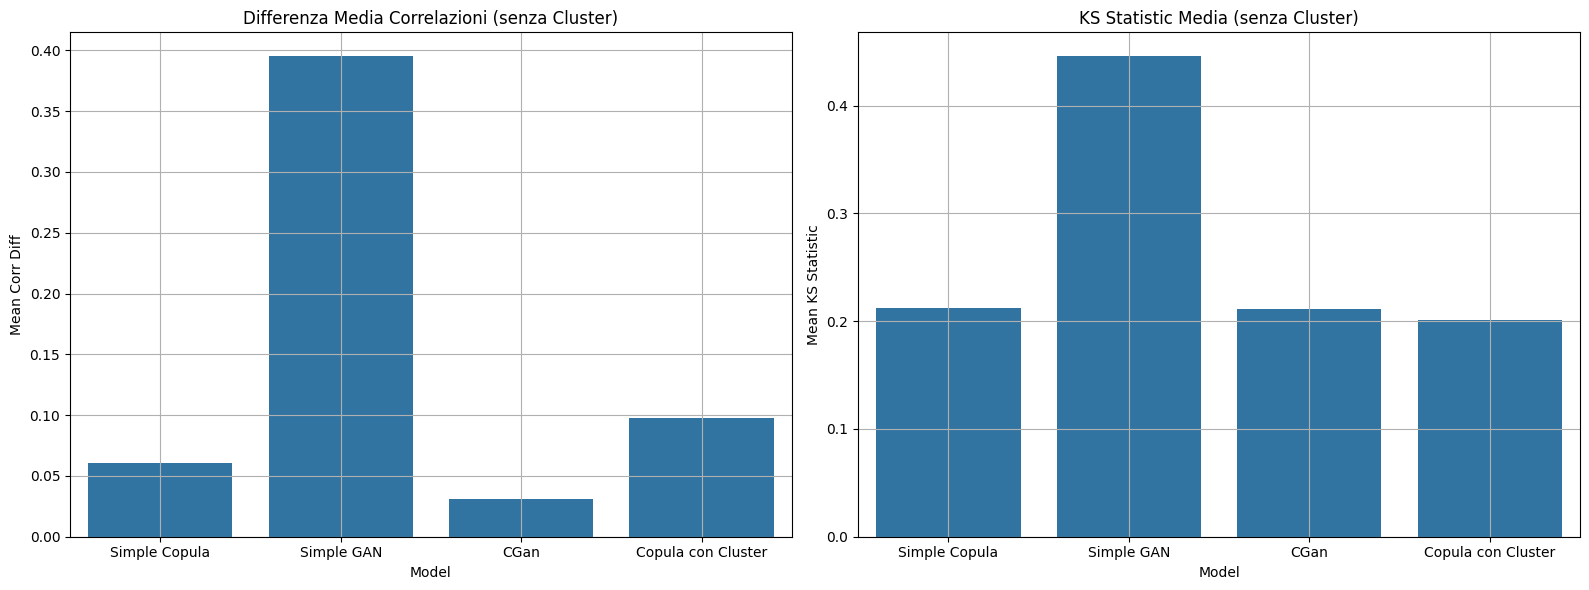


 Grafico salvato in: outfit_copy/output_comparison_no_cluster/comparison_plot.png


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === CONFIG ===
models = ['copula_semplice', 'gan_semplice','gan_condizionale','copula_clusters']
labels = ['Simple Copula', 'Simple GAN' ,'CGan' , 'Copula con Cluster' ]
suffixes = ['copula', 'gan' , 'cgan' , 'copula_clusters']
paths = ['outfit_copy/output_copula_semplice',
         'outfit_copy/output_gan_semplice',         
         'outfit_copy/output_gan_condizionale',
         'outfit_copy/output_copula_clusters'
         
         ]

# === RISULTATI ===
os.makedirs('outfit_copy/output_comparison_no_cluster', exist_ok=True)

# === MATRICE ORIGINALE senza cluster ===
corr_matrix_original = pd.read_csv('corr_matrix_original.csv', index_col=0)
if 'Cluster' in corr_matrix_original.columns:
    corr_matrix_original = corr_matrix_original.drop(columns='Cluster')
if 'Cluster' in corr_matrix_original.index:
    corr_matrix_original = corr_matrix_original.drop(index='Cluster')


# === METRICHE ===
corr_diff_means = {}
ks_stat_means = {}
ks_pvalue_means = {}
wasserstein_means = {}
mutual_info_means = {}
js_means = {}              
mean_diff_means = {}      
var_diff_means = {}


# === LOOP SUI MODELLI ===
for model, suffix, path in zip(models, suffixes, paths):
    print(f"\n▶ Analizzo modello: {model}")
    # Correlazione : vado ad eliminare i cluster nei modelli condizionali 
    corr_no_cluster = pd.read_csv(f'{path}/corr_matrix_{suffix}.csv', index_col=0)
   
    if 'Cluster' in corr_no_cluster.columns:
        corr_no_cluster = corr_no_cluster.drop(columns='Cluster')
    if 'Cluster' in corr_no_cluster.index:
        corr_no_cluster = corr_no_cluster.drop(index='Cluster')


    
    diff_no_cluster = np.abs(corr_no_cluster - corr_matrix_original)
    values_no_cluster = diff_no_cluster.to_numpy()[np.triu_indices_from(diff_no_cluster, k=1)]
    corr_diff_means[model] = np.mean(values_no_cluster)

    # KS
    ks = pd.read_csv(f'{path}/ks_comparison_{suffix}.csv', index_col=0)
    if 'Cluster' in ks.index:
        ks = ks.drop(index='Cluster')
    ks_stat_means[model] = ks['KS Statistic'].mean()
    ks_pvalue_means[model] = ks['p-value'].mean()

    # Wasserstein
    ws = pd.read_csv(f'{path}/wasserstein_{suffix}.csv', index_col=0)
    if 'Cluster' in ws.index:
        ws = ws.drop(index='Cluster')
    wasserstein_means[model] = ws['Wasserstein Distance'].mean()

    # Mutual Info
    mi = pd.read_csv(f'{path}/mutual_info_{suffix}.csv', index_col=0)
    if 'Cluster' in mi.index:
        mi = mi.drop(index='Cluster')
    mutual_info_means[model] = mi['Mutual Information'].mean()

    # --- Jensen-Shannon ---
    js_df = pd.read_csv(f'{path}/js_distance_{suffix}.csv', index_col=0)
    js_means[model] = js_df['JS Distance'].mean()

    # --- Mean/Var Difference ---
    stats_df = pd.read_csv(f'{path}/mae_stats_{suffix}.csv', index_col=0)
    mean_diff_means[model] = stats_df['Mean Difference'].mean()
    var_diff_means[model] = stats_df['Variance Difference'].mean()

# === OUTPUT ===
df_summary = pd.DataFrame({
    'Model': labels,
    'Mean Corr Diff': [corr_diff_means[m] for m in models],
    'Mean KS Statistic': [ks_stat_means[m] for m in models],
    'Mean KS p-value': [ks_pvalue_means[m] for m in models],
    'Mean Wasserstein': [wasserstein_means[m] for m in models],
    'Mean Mutual Info': [mutual_info_means[m] for m in models],
    'Mean JS Distance': [js_means[m] for m in models],
    'Mean Diff': [mean_diff_means[m] for m in models],
    'Variance Diff': [var_diff_means[m] for m in models]
})

df_summary.to_csv('outfit_copy/output_comparison_no_cluster/comparison_summary_all_metrics.csv', index=False)
print("\n Tabella salvata in: outfit_copy/output_comparison_no_cluster/comparison_summary_all_metrics.csv")
print(df_summary.to_string(index=False))

# === GRAFICO ===
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Mean Corr Diff', data=df_summary)
plt.title('Differenza Media Correlazioni (senza Cluster)')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Mean KS Statistic', data=df_summary)
plt.title('KS Statistic Media (senza Cluster)')
plt.grid(True)

plt.tight_layout()
plt.savefig('outfit_copy/output_comparison_no_cluster/comparison_plot.png')
plt.show()
print("\n Grafico salvato in: outfit_copy/output_comparison_no_cluster/comparison_plot.png")
